In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Creating a mock CSV dataset for demonstration
sample_csv = """Ticker,Sector,Quantity,Buy_Price,Current_Price
AAPL,Technology,10,150.00,185.50
MSFT,Technology,5,280.00,420.00
JNJ,Healthcare,12,160.00,152.00
JPM,Financials,8,140.00,195.00
XOM,Energy,15,105.00,118.00
TSLA,Automotive,6,240.00,175.00
"""

#creating the CSV file
with open('portfolio.csv', 'w') as f:
    f.write(sample_csv)

# Read data from CSV
df = pd.read_csv('portfolio.csv')

In [7]:
# Calculate Total Invested and Current Value
df["Total_Invested"] = df["Quantity"] * df["Buy_Price"]
df["Current_Value"] = df["Quantity"] * df["Current_Price"]

# Profit / Loss in currency and percentage
df["Profit_Loss"] = df["Current_Value"] - df["Total_Invested"]
df["Return_Pct"] = (df["Profit_Loss"] / df["Total_Invested"]) * 100

In [6]:
best_stock = df.loc[df["Return_Pct"].idxmax()]
worst_stock = df.loc[df["Return_Pct"].idxmin()]

total_portfolio_invested = df["Total_Invested"].sum()
total_portfolio_current = df["Current_Value"].sum()
total_portfolio_pnl = total_portfolio_current - total_portfolio_invested
portfolio_return_pct = (
    total_portfolio_pnl / total_portfolio_invested
) * 100

print(f"Total Invested: ${total_portfolio_invested:,.2f}")
print(f"Current Value : ${total_portfolio_current:,.2f}")
print(
    f"Total Profit  : ${total_portfolio_pnl:,.2f} ({portfolio_return_pct:.2f}%)"
)

Total Invested: $8,955.00
Current Value : $10,159.00
Total Profit  : $1,204.00 (13.45%)


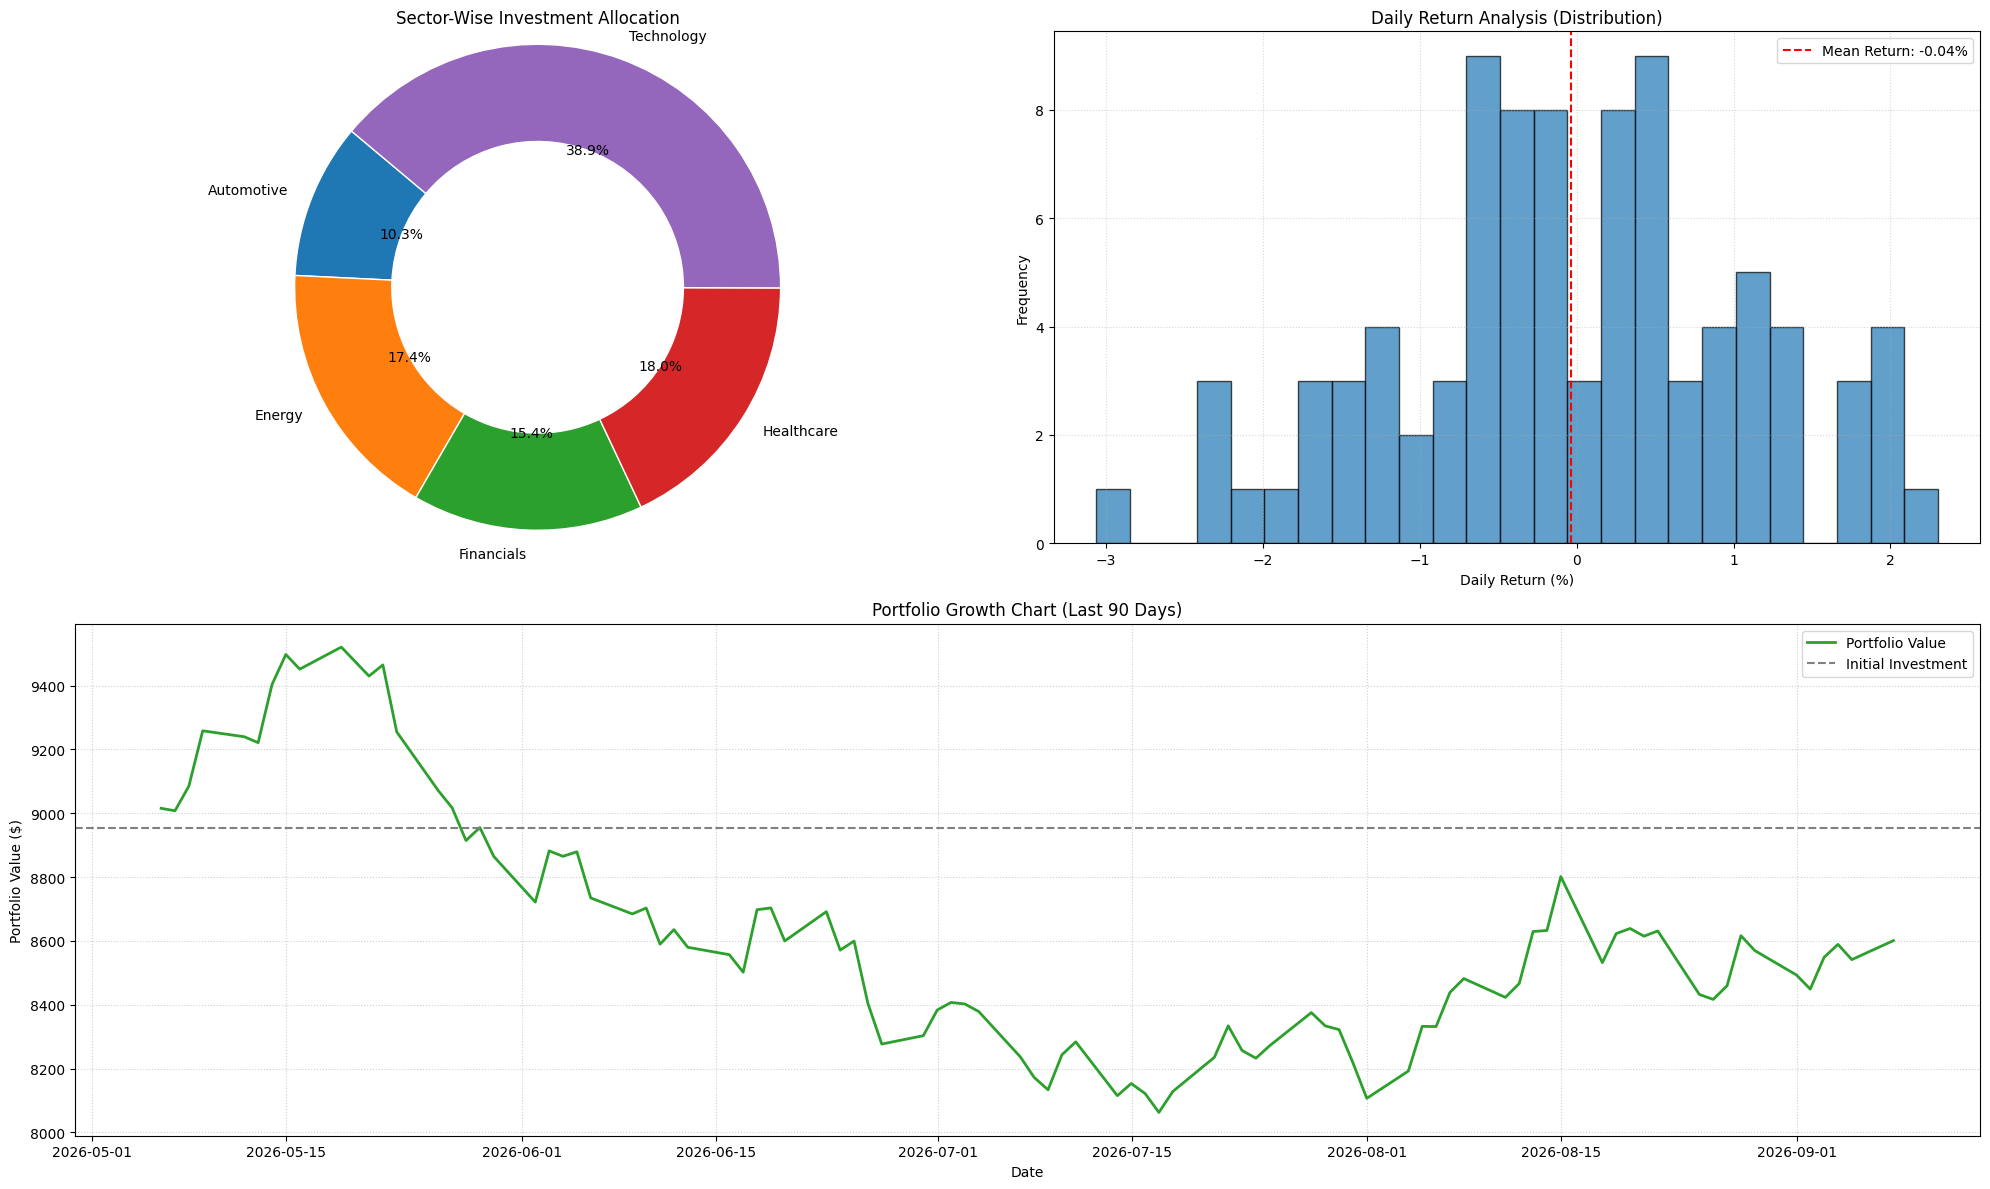

In [20]:
# Generate synthetic 90-day time-series data
np.random.seed(42)
dates = pd.date_range(end=pd.Timestamp.today(), periods=90, freq="B")
daily_pct_changes = np.random.normal(0.0008, 0.012, size=len(dates))

# Compound growth from total invested capital
cumulative_growth = (1 + daily_pct_changes).cumprod()
portfolio_history = total_portfolio_invested * cumulative_growth

fig,axes = plt.subplot_mosaic([['left', 'right'],
                                ['bottom', 'bottom']],
                                  figsize=(20, 12))

# Plot Portfolio Growth
axes['bottom'].plot(
    dates,
    portfolio_history,
    color="#2ca02c",
    linewidth=2,
    label="Portfolio Value",
)
axes['bottom'].axhline(
    total_portfolio_invested,
    color="gray",
    linestyle="--",
    label="Initial Investment",
)
axes['bottom'].set_title("Portfolio Growth Chart (Last 90 Days)")
axes['bottom'].set_xlabel("Date")
axes['bottom'].set_ylabel("Portfolio Value ($)")
axes['bottom'].legend()
axes['bottom'].grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

#PIE CHART
sector_allocation = df.groupby("Sector")["Current_Value"].sum()
axes['left'].pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="w"),
)
axes['left'].set_title("Sector-Wise Investment Allocation")
axes['left'].axis("equal")
plt.tight_layout()

# Histogram of Daily Returns
axes['right'].hist(
    daily_pct_changes * 100,
    bins=25,
    color="#1f77b4",
    edgecolor="black",
    alpha=0.7,
)
axes['right'].axvline(
    daily_pct_changes.mean() * 100,
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label=f"Mean Return: {daily_pct_changes.mean()*100:.2f}%",
)
axes['right'].set_title("Daily Return Analysis (Distribution)")
axes['right'].set_xlabel("Daily Return (%)")
axes['right'].set_ylabel("Frequency")
axes['right'].legend()
axes['right'].grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

plt.show()